In [4]:
import pandas as pd

# Load full quantum features
df = pd.read_csv("../quantum_raw_parkinsons_gait_percent.csv")

print(f"✅ Loaded full quantum features: {df.shape[1]} columns.")

✅ Loaded full quantum features: 12 columns.


In [5]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    # Accuracy Plot
    axs[0].plot(history.history['accuracy'], label="Train Accuracy")
    axs[0].plot(history.history['val_accuracy'], label="Validation Accuracy")
    axs[0].set_title(f"Model Accuracy - {title}")
    axs[0].set_xlabel("Epochs")
    axs[0].set_ylabel("Accuracy")
    axs[0].legend()

    # Loss Plot
    axs[1].plot(history.history['loss'], label="Train Loss")
    axs[1].plot(history.history['val_loss'], label="Validation Loss")
    axs[1].set_title(f"Model Loss - {title}")
    axs[1].set_xlabel("Epochs")
    axs[1].set_ylabel("Loss")
    axs[1].legend()

    plt.show()

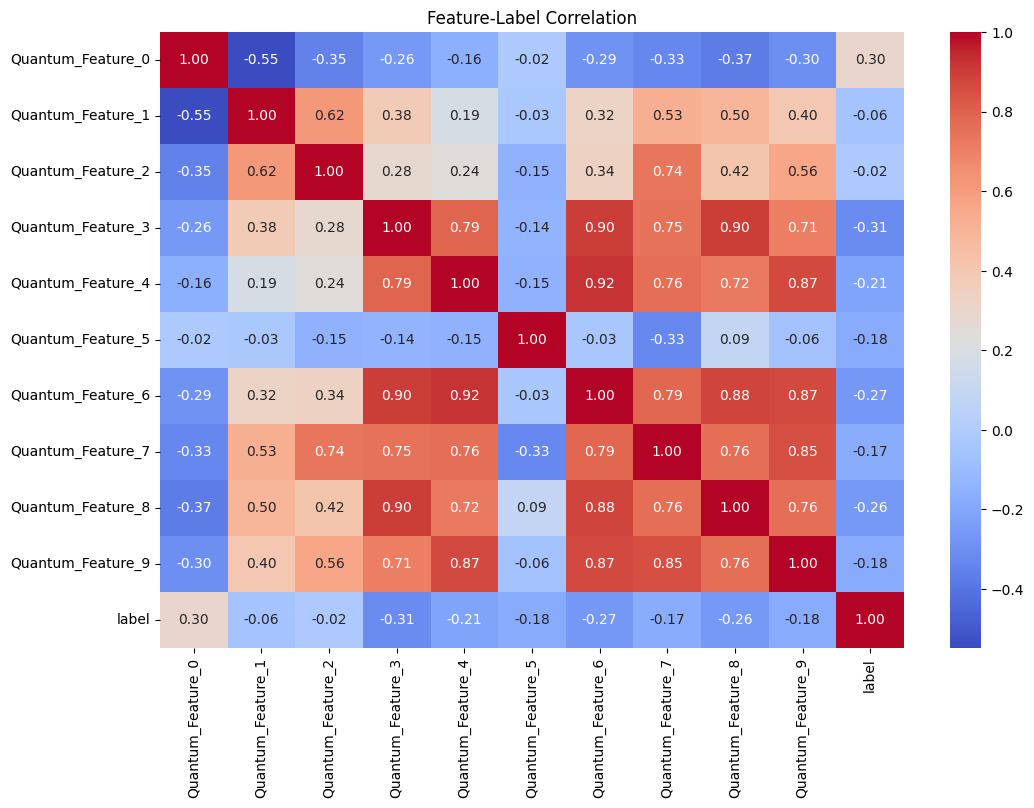

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

df = df.drop(columns=["Subject_ID"])
df_corr = df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(df_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature-Label Correlation")
plt.show()

In [7]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.layers import BatchNormalization, Dropout

tf.keras.backend.set_floatx('float32')

# Ensure features and labels are correctly extracted
X = df.drop(columns=["label"]).values  # Features
y = df["label"].values  # Labels

# Convert labels to one-hot encoding *before* splitting
y_onehot = tf.keras.utils.to_categorical(y, num_classes=2)

# Split once: train + temp
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y_onehot, random_state=42)

# Split again: train + val (from temp)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

# ✅ Remove MinMaxScaler, keep StandardScaler
scaler = StandardScaler()  # StandardScaler ensures proper feature scaling for PCA
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

# Convert to float32 (required for TensorFlow)
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")
y_train = y_train.astype("float32")
X_val = X_val.astype("float32")

print(f"✅ X_train Labels shape: {y_train.shape}, {y_train.shape}")
print(f"✅ X_val Labels shape: {y_val.shape}, {y_val.shape}")
print(f"✅ X_test Labels shape: {y_test.shape}, {y_test.shape}")


✅ X_train Labels shape: (2908,), (2908,)
✅ X_val Labels shape: (970,), (970,)
✅ X_test Labels shape: (970,), (970,)


In [9]:
print("X_train shape:", X_train.shape)

X_train shape: (2908, 10)


In [10]:
# Expand feature dimension for CNN/Transformer
X_train_seq = np.expand_dims(X_train, axis=-1)
X_val_seq   = np.expand_dims(X_val, axis=-1)
X_test_seq  = np.expand_dims(X_test, axis=-1)

print("Reshaped CNN input:", X_train_seq.shape)  # (2908, 10, 1)

Reshaped CNN input: (2908, 10, 1)


# CNN Baseline

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

def build_cnn_baseline(input_shape):
    model = models.Sequential([
        layers.Conv1D(64, kernel_size=3, activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        
        layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),
        
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-4),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Run CNN baseline
cnn_model = build_cnn_baseline((X_train_seq.shape[1], X_train_seq.shape[2]))
history_cnn = cnn_model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)
cnn_results = cnn_model.evaluate(X_val_seq, y_val, verbose=0)
print(f"CNN Baseline Validation Accuracy: {cnn_results[1]*100:.2f}%")

Epoch 1/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7634 - loss: 0.5174 - val_accuracy: 0.8237 - val_loss: 0.6602
Epoch 2/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8483 - loss: 0.3686 - val_accuracy: 0.5206 - val_loss: 0.6340
Epoch 3/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8673 - loss: 0.3196 - val_accuracy: 0.5206 - val_loss: 0.5957
Epoch 4/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8800 - loss: 0.2911 - val_accuracy: 0.6113 - val_loss: 0.5239
Epoch 5/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8762 - loss: 0.2913 - val_accuracy: 0.7711 - val_loss: 0.4633
Epoch 6/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8838 - loss: 0.2754 - val_accuracy: 0.8876 - val_loss: 0.3174
Epoch 7/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8858 - loss: 0.2692 - val_accuracy: 0.8763 - val_loss: 0.2956
Epoch 8/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8834 - loss: 0.2675 - val_accuracy: 0.9062 - val_loss:

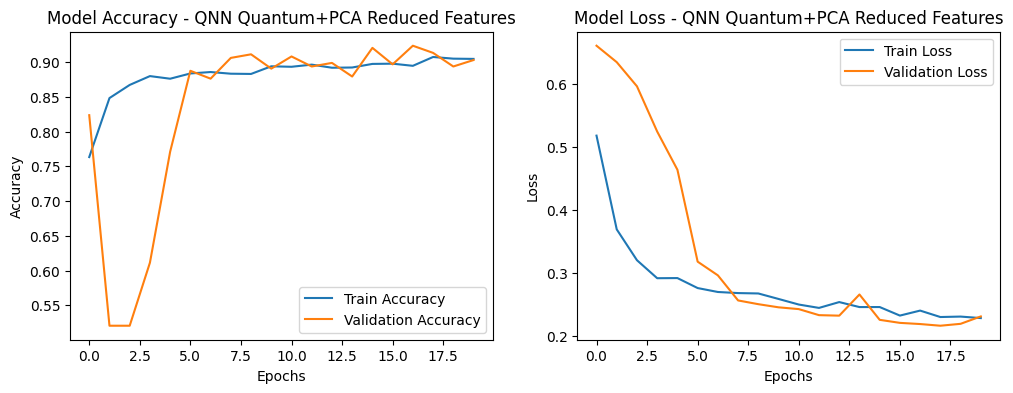

In [13]:
plot_history(history_cnn, "QNN Quantum+PCA Reduced Features")

In [ ]:
# ✅ Evaluate
test_loss, test_acc = cnn_model.evaluate(X_test_seq, y_test)
print(f"QNN Test Accuracy: {test_acc:.4f} | Loss: {test_loss:.4f}")

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8742 - loss: 0.2580 
QNN Test Accuracy: 0.8742 | Loss: 0.2580


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


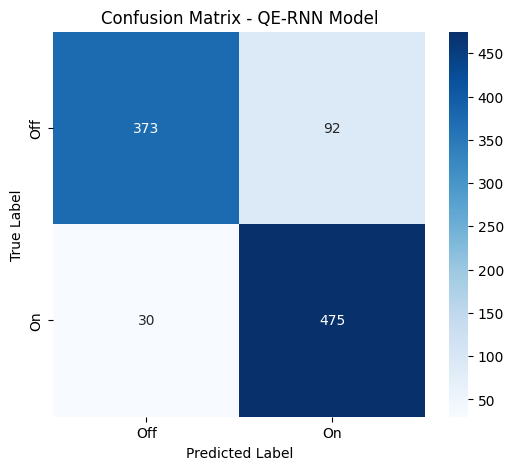

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.80      0.86       465
           1       0.84      0.94      0.89       505

    accuracy                           0.87       970
   macro avg       0.88      0.87      0.87       970
weighted avg       0.88      0.87      0.87       970



In [16]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 🔹 Step 1: Get prediction probabilities
y_pred_probs = cnn_model.predict(X_test)

# 🔹 Step 2: Binarize predictions (assuming sigmoid output layer)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# 🔹 Step 3: Decode true labels if they're one-hot encoded
if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_test = np.argmax(y_test, axis=1)  # convert [0,1] to 1 and [1,0] to 0

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt=".0f", cmap="Blues",
            xticklabels=["Off", "On"], yticklabels=["Off", "On"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - QE-RNN Model")
plt.show()

print("Classification Report:\n", classification_report(y_test, y_pred))

# Confidence Check

In [17]:
import numpy as np

# Get model predictions
y_pred_probs = cnn_model.predict(X_test)

# Check confidence distribution
print("Min Confidence:", np.min(y_pred_probs))
print("Max Confidence:", np.max(y_pred_probs))
print("Mean Confidence:", np.mean(y_pred_probs))

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Min Confidence: 0.017328158
Max Confidence: 1.0
Mean Confidence: 0.57460207


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


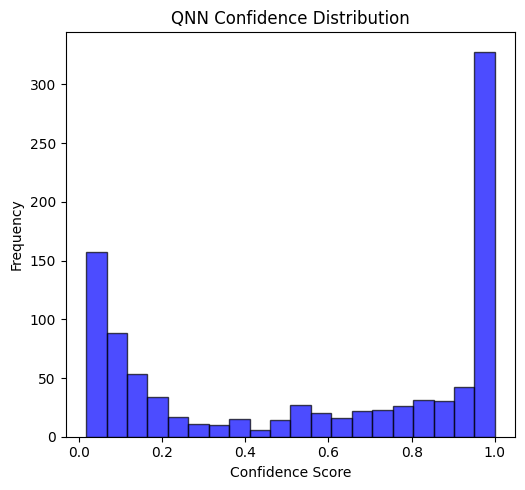

In [18]:
y_true_qnn = y_test# Convert one-hot labels to class labels
y_pred_qnn = np.argmax(cnn_model.predict(X_test), axis=1)
confidences_qnn = np.max(cnn_model.predict(X_test), axis=1)

# Convert to numpy arrays if needed
qnn_confidences = np.array(confidences_qnn)  # Replace with your QNN confidence list

plt.figure(figsize=(10, 5))

# QNN Confidence Distribution
plt.subplot(1, 2, 1)
plt.hist(qnn_confidences, bins=20, color='blue', alpha=0.7, edgecolor='black')
plt.title("QNN Confidence Distribution")
plt.xlabel("Confidence Score")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# K-Fold

In [23]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import KFold

# --- Ensure correct shape ---
X_seq = np.expand_dims(X_train, axis=-1)  # (samples, 10, 1)
print("CNN input shape:", X_seq.shape)

# --- K-Fold setup ---
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

train_accs, val_accs, train_losses, val_losses = [], [], [], []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_seq)):
    print(f"\n🚀 Training Fold {fold+1}/{k}")

    X_train_fold, X_val_fold = X_seq[train_idx], X_seq[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

    # --- CNN baseline definition ---
    model = tf.keras.Sequential([
        tf.keras.layers.Conv1D(32, kernel_size=3, activation='relu', input_shape=(X_seq.shape[1], 1)),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Conv1D(64, kernel_size=3, activation='relu'),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4, clipvalue=0.5),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # --- Train ---
    history = model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=20, batch_size=32, verbose=1
    )

    # --- Record last-epoch stats ---
    train_accs.append(history.history['accuracy'])
    val_accs.append(history.history['val_accuracy'])
    train_losses.append(history.history['loss'])
    val_losses.append(history.history['val_loss'])

    val_eval = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    print(f"Fold {fold+1} Validation Accuracy: {val_eval[1]*100:.2f}%")

# --- Summarize ---
print("\n📊 Final K-Fold Results (CNN Baseline):")
print(f"Train Accuracy: {np.mean(train_accs):.4f} ± {np.std(train_accs):.4f}")
print(f"Val Accuracy:   {np.mean(val_accs):.4f} ± {np.std(val_accs):.4f}")
print(f"Train Loss:     {np.mean(train_losses):.4f} ± {np.std(train_losses):.4f}")
print(f"Val Loss:       {np.mean(val_losses):.4f} ± {np.std(val_losses):.4f}")

CNN input shape: (2908, 10, 1)

🚀 Training Fold 1/5
Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5249 - loss: 0.6642 - val_accuracy: 0.4931 - val_loss: 0.6475
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5413 - loss: 0.6348 - val_accuracy: 0.6014 - val_loss: 0.6179
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6466 - loss: 0.6059 - val_accuracy: 0.8162 - val_loss: 0.5845
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7635 - loss: 0.5733 - val_accuracy: 0.8505 - val_loss: 0.5464
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8009 - loss: 0.5410 - val_accuracy: 0.8488 - val_loss: 0.5086
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8169 - loss: 0.5078 - val_accuracy: 0.8625 - val_loss: 0.4712
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8229 - loss: 0.4776 - val_accuracy: 0.8711 - val_loss: 0.4344
Epoch 8/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.82


Final CNN K-Fold Validation Accuracy: 0.8569


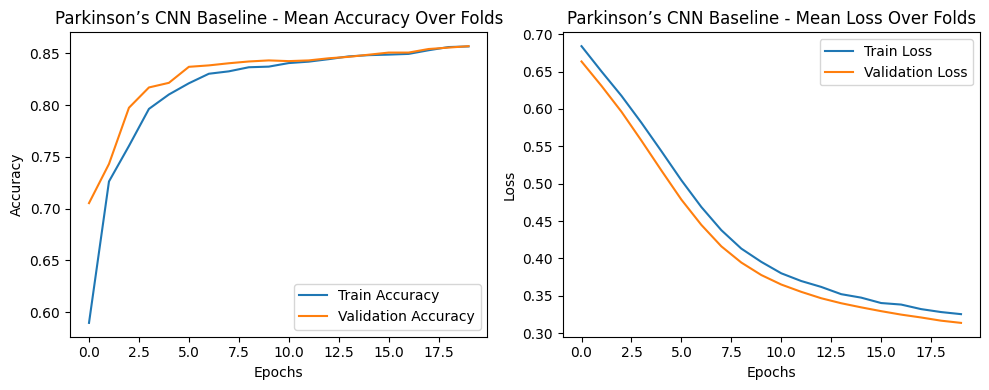

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# --- Convert lists to arrays ---
train_accs = np.array(train_accs)
val_accs = np.array(val_accs)
train_losses = np.array(train_losses)
val_losses = np.array(val_losses)

# --- Compute mean across folds (per epoch) ---
mean_train_acc = np.mean(train_accs, axis=0)
mean_val_acc = np.mean(val_accs, axis=0)
mean_train_loss = np.mean(train_losses, axis=0)
mean_val_loss = np.mean(val_losses, axis=0)

# --- Final mean accuracy (last epoch) ---
final_accuracy = np.mean(val_accs[:, -1])
print(f"\nFinal CNN K-Fold Validation Accuracy: {final_accuracy:.4f}")

# --- Plotting ---
plt.figure(figsize=(10, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(mean_train_acc, label='Train Accuracy')
plt.plot(mean_val_acc, label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Parkinson’s CNN Baseline - Mean Accuracy Over Folds")
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(mean_train_loss, label='Train Loss')
plt.plot(mean_val_loss, label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Parkinson’s CNN Baseline - Mean Loss Over Folds")
plt.legend()

plt.tight_layout()
plt.show()

In [25]:
import pandas as pd
import numpy as np

# Convert lists to numpy arrays
folds = list(range(1, len(train_accs) + 1))

# Create DataFrame with results per fold
df_results = pd.DataFrame({
    'Fold': folds,
    'Final Train Accuracy': [train_acc[-1] for train_acc in train_accs],
    'Final Validation Accuracy': [val_acc[-1] for val_acc in val_accs],
    'Final Train Loss': [train_loss[-1] for train_loss in train_losses],
    'Final Validation Loss': [val_loss[-1] for val_loss in val_losses]
})

# Print results
print("\n📊 K-Fold Cross-Validation Results:\n")
print(df_results)

# Compute summary statistics (mean & std deviation)
df_summary = df_results.describe().loc[['mean', 'std']]
print("\n📌 Summary Statistics (Mean & Std Deviation):\n")
print(df_summary)


📊 K-Fold Cross-Validation Results:

   Fold  Final Train Accuracy  Final Validation Accuracy  Final Train Loss  \
0     1              0.854256                   0.879725          0.333540   
1     2              0.850387                   0.871134          0.335782   
2     3              0.855546                   0.852234          0.325093   
3     4              0.855178                   0.836489          0.322971   
4     5              0.868070                   0.845095          0.310303   

   Final Validation Loss  
0               0.273400  
1               0.302810  
2               0.324198  
3               0.346829  
4               0.322028  

📌 Summary Statistics (Mean & Std Deviation):

          Fold  Final Train Accuracy  Final Validation Accuracy  \
mean  3.000000              0.856688                   0.856935   
std   1.581139              0.006685                   0.018037   

      Final Train Loss  Final Validation Loss  
mean          0.325538             